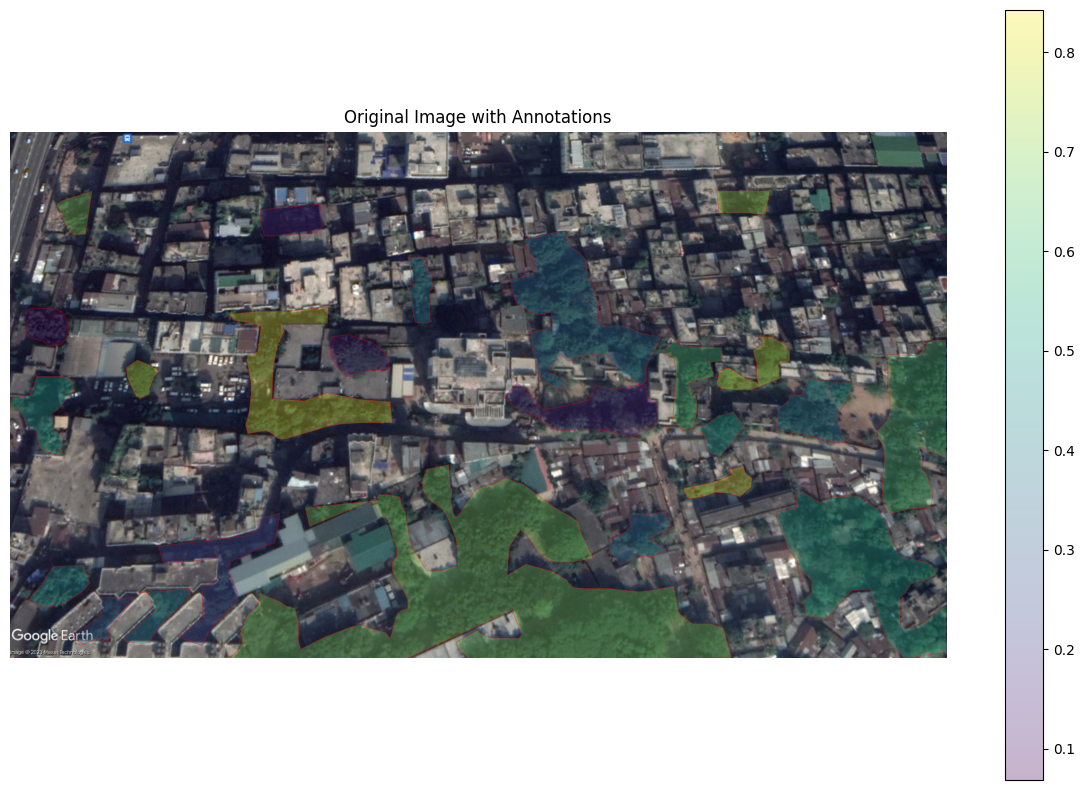

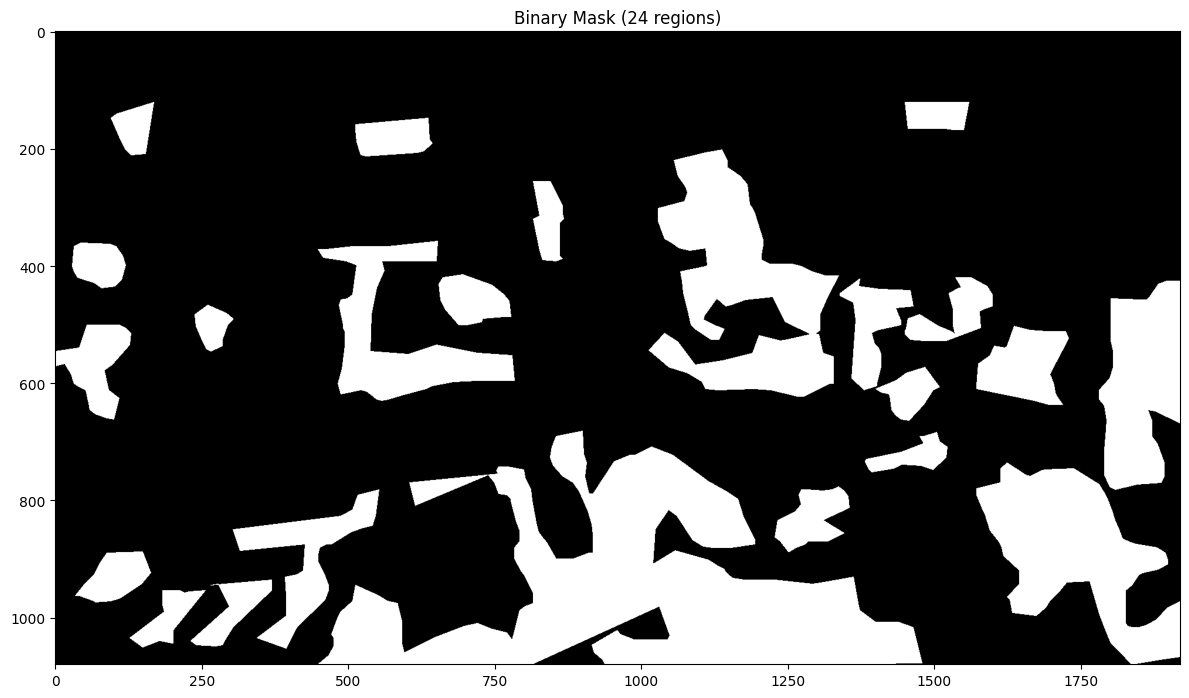

In [7]:
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

def main():
    # Set paths to your files
    json_path = "/kaggle/input/exampleimage/2019Mohakhali (1).json"
    image_path = "/kaggle/input/exampleimage/2019Mohakhali (1).jpg"

    # Load JSON data
    with open(json_path, 'r', encoding='utf-8') as f:
        json_data = json.load(f)
    
    # Load image
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Get the first file's data
    file_key = next(iter(json_data.keys()))
    regions = json_data[file_key]['regions']

    # Create figure for original image with annotations
    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    plt.title("Original Image with Annotations")
    plt.axis('off')

    # Create mask and patches
    mask = np.zeros(image.shape[:2], dtype=np.uint8)
    patches = []
    colors = []

    for region_id, region in regions.items():
        if region['shape_attributes']['name'] == 'polygon':
            x_points = region['shape_attributes']['all_points_x']
            y_points = region['shape_attributes']['all_points_y']
            polygon = np.column_stack((x_points, y_points))
            
            # Add to mask
            cv2.fillPoly(mask, [np.array(polygon, dtype=np.int32)], 255)
            
            # Create patch and random color
            patches.append(Polygon(polygon, closed=True))
            colors.append(np.random.rand())  # Single scalar value for colormapping

    # Add patches to plot (only if we have any)
    if patches:
        # Create PatchCollection with facecolors
        p = PatchCollection(patches, alpha=0.3, edgecolor='red', linewidth=0.7)
        
        # Use set_array with 1D array of scalar values
        p.set_array(np.array(colors))  # Now using 1D array of scalars
        
        # Add to plot
        plt.gca().add_collection(p)
        plt.colorbar(p)  # Optional: show colorbar

    # Show and save original annotated image
    plt.tight_layout()
    plt.savefig("original_annotated.png", dpi=300, bbox_inches='tight')
    plt.show()

    # Create figure for binary mask
    plt.figure(figsize=(12, 8))
    plt.imshow(mask, cmap='gray')
    plt.title(f"Binary Mask ({len(patches)} regions)")
    
    # Show and save binary mask
    plt.tight_layout()
    plt.savefig("binary_mask.png", dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    main()